In [1]:
import pandas as pd

In [2]:
import os

In [3]:
os.getcwd()

'C:\\Users\\Nikhil Agrawal'

In [10]:
os.chdir('C:\\Users\\Nikhil Agrawal\\Downloads')

In [12]:
data=pd.read_csv("orders.csv")

In [13]:
data.head(10)

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name
0,1,2508,450,18-02-2023,842.97,New Foods Chinese
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian
5,6,2933,499,12-07-2023,1497.22,Annapurna Tiffins South Indian
6,7,970,35,30-05-2023,129.21,Royal Biryani North Indian
7,8,891,57,07-11-2023,269.19,Spice Mess Punjabi
8,9,364,7,05-12-2023,953.30,Ruchi Biryani Punjabi
9,10,2972,183,30-12-2023,351.41,Taste of Biryani Non-Veg


In [14]:
data.tail(10)

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name
9990,9991,2606,177,20-03-2023,953.99,Udupi Restaurant South Indian
9991,9992,2911,275,07-11-2023,457.90,Classic Eatery South Indian
9992,9993,2519,33,23-02-2023,692.26,Amma Foods Non-Veg
9993,9994,1616,198,28-04-2023,322.54,Annapurna Tiffins North Indian
9994,9995,1257,328,12-11-2023,137.96,Ruchi Curry House Andhra
9995,9996,2528,249,21-05-2023,1211.96,Royal Kitchen North Indian
9996,9997,2867,267,06-08-2023,1188.05,Darbar Cafe Punjabi
9997,9998,522,420,11-11-2023,979.44,Ruchi Tiffins Chinese
9998,9999,319,492,08-09-2023,1105.93,Swagath Kitchen North Indian
9999,10000,457,439,21-10-2023,879.58,Classic Cafe Family Restaurant


In [15]:
import json

In [18]:
with open("C:\\Users\\Nikhil Agrawal\\Downloads\\users.json", "r") as f:
    data = json.load(f)

print(data)

[{'user_id': 1, 'name': 'User_1', 'city': 'Chennai', 'membership': 'Regular'}, {'user_id': 2, 'name': 'User_2', 'city': 'Pune', 'membership': 'Gold'}, {'user_id': 3, 'name': 'User_3', 'city': 'Bangalore', 'membership': 'Gold'}, {'user_id': 4, 'name': 'User_4', 'city': 'Bangalore', 'membership': 'Regular'}, {'user_id': 5, 'name': 'User_5', 'city': 'Pune', 'membership': 'Gold'}, {'user_id': 6, 'name': 'User_6', 'city': 'Pune', 'membership': 'Gold'}, {'user_id': 7, 'name': 'User_7', 'city': 'Chennai', 'membership': 'Gold'}, {'user_id': 8, 'name': 'User_8', 'city': 'Hyderabad', 'membership': 'Regular'}, {'user_id': 9, 'name': 'User_9', 'city': 'Bangalore', 'membership': 'Gold'}, {'user_id': 10, 'name': 'User_10', 'city': 'Chennai', 'membership': 'Regular'}, {'user_id': 11, 'name': 'User_11', 'city': 'Chennai', 'membership': 'Gold'}, {'user_id': 12, 'name': 'User_12', 'city': 'Pune', 'membership': 'Regular'}, {'user_id': 13, 'name': 'User_13', 'city': 'Chennai', 'membership': 'Gold'}, {'use

In [25]:
pip install ipywidgets


In [26]:
conda install -c conda-forge ipywidgets



Note: you may need to restart the kernel to use updated packages.


'C:\Users\Nikhil' is not recognized as an internal or external command,
operable program or batch file.


In [27]:
from ipywidgets import FileUpload

upload = FileUpload(accept='C:\\Users\\Nikhil Agrawal\\Downloads\\restaurants.sql', multiple=False)
upload


FileUpload(value=(), accept='C:\\Users\\Nikhil Agrawal\\Downloads\\restaurants.sql', description='Upload')

In [33]:
import sqlite3

conn = sqlite3.connect('restaurants.db')
cursor = conn.cursor()

with open('restaurants.sql', 'r') as file:
    sql_script = file.read()

cursor.executescript(sql_script)
conn.commit()


In [34]:
df = pd.read_sql("SELECT * FROM restaurants", conn)
df.head()

,restaurant_id,restaurant_name,cuisine,rating
0,1,Restaurant_1,Chinese,4.8
1,2,Restaurant_2,Indian,4.1
2,3,Restaurant_3,Mexican,4.3
3,4,Restaurant_4,Chinese,4.1
4,5,Restaurant_5,Chinese,4.8


In [35]:
orders = pd.read_csv('orders.csv')

In [36]:
users = pd.read_json('users.json')

In [37]:
conn = sqlite3.connect('restaurants.db')

restaurants = pd.read_sql(
    "SELECT * FROM restaurants",
    conn
)


In [38]:
print(orders.columns)
print(users.columns)
print(restaurants.columns)


Index(['order_id', 'user_id', 'restaurant_id', 'order_date', 'total_amount',
       'restaurant_name'],
      dtype='object')
Index(['user_id', 'name', 'city', 'membership'], dtype='object')
Index(['restaurant_id', 'restaurant_name', 'cuisine', 'rating'], dtype='object')


In [39]:
data = pd.merge(
    orders,
    users,
    on='user_id',
    how='left'
)

In [40]:
final_data = pd.merge(
    data,
    restaurants,
    on='restaurant_id',
    how='left'
)


In [41]:
final_data.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [42]:
orders = pd.read_csv('orders.csv')
users = pd.read_json('users.json')

merged = orders.merge(users, on='user_id', how='left')


In [47]:
merged.to_csv("final_food_delivery_dataset.csv", index=False)
print("Final dataset saved successfully!")


Final dataset saved successfully!


In [52]:
os.chdir('C:\\Users\\Nikhil Agrawal\\Downloads')

In [54]:
data=pd.read_csv("final_food_delivery_dataset.csv")

In [55]:
data.head(5)

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name,name,city,membership
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular


In [56]:
data.tail(5)

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name,name,city,membership
9995,9996,2528,249,21-05-2023,1211.96,Royal Kitchen North Indian,User_2528,Hyderabad,Gold
9996,9997,2867,267,06-08-2023,1188.05,Darbar Cafe Punjabi,User_2867,Bangalore,Regular
9997,9998,522,420,11-11-2023,979.44,Ruchi Tiffins Chinese,User_522,Bangalore,Gold
9998,9999,319,492,08-09-2023,1105.93,Swagath Kitchen North Indian,User_319,Bangalore,Gold
9999,10000,457,439,21-10-2023,879.58,Classic Cafe Family Restaurant,User_457,Chennai,Regular


In [62]:
# Load CSV (orders)
orders = pd.read_csv('orders.csv')

# Load JSON (users)
users = pd.read_json('users.json')

# Load SQL (restaurants)
conn = sqlite3.connect('restaurants.db')
restaurants = pd.read_sql("SELECT * FROM restaurants", conn)

In [63]:
# Merge orders with users
merged_data = orders.merge(users, on='user_id', how='left')

# Merge result with restaurants
final_dataset = merged_data.merge(restaurants, on='restaurant_id', how='left')

# Preview the dataset
final_dataset.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [68]:
print(final_dataset.columns)

Index(['order_id', 'user_id', 'restaurant_id', 'order_date', 'total_amount',
       'restaurant_name_x', 'name', 'city', 'membership', 'restaurant_name_y',
       'cuisine', 'rating'],
      dtype='object')


In [71]:
# Suppose your column is named 'order_amount'
final_dataset.rename(columns={'order_amount': 'total_amount'}, inplace=True)

In [72]:
# Convert order_date to datetime
final_dataset['order_date'] = pd.to_datetime(final_dataset['order_date'], dayfirst=True, errors='coerce')

# Fill missing amounts
final_dataset['total_amount'] = final_dataset['total_amount'].fillna(0)

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load files
orders = pd.read_csv('orders.csv')
users = pd.read_json('users.json')
conn = sqlite3.connect('restaurants.db')
restaurants = pd.read_sql("SELECT * FROM restaurants", conn)

# 2️⃣ Merge datasets
merged_data = orders.merge(users, on='user_id', how='left')
final_dataset = merged_data.merge(restaurants, on='restaurant_id', how='left')

# 3️⃣ Check columns
print(final_dataset.columns)

# 4️⃣ Rename order amount column if needed
if 'order_amount' in final_dataset.columns:
    final_dataset.rename(columns={'order_amount': 'total_amount'}, inplace=True)

# 5️⃣ Convert date column
final_dataset['order_date'] = pd.to_datetime(final_dataset['order_date'], dayfirst=True, errors='coerce')

# 6️⃣ Fill missing amounts
final_dataset['total_amount'] = final_dataset['total_amount'].fillna(0)

# 7️⃣ Preview
print(final_dataset.head())

Index(['order_id', 'user_id', 'restaurant_id', 'order_date', 'total_amount',
       'restaurant_name_x', 'name', 'city', 'membership', 'restaurant_name_y',
       'cuisine', 'rating'],
      dtype='object')
   order_id  user_id  restaurant_id order_date  total_amount  \
0         1     2508            450 2023-02-18        842.97   
1         2     2693            309 2023-01-18        546.68   
2         3     2084            107 2023-07-15        163.93   
3         4      319            224 2023-10-04       1155.97   
4         5     1064            293 2023-12-25       1321.91   

                restaurant_name_x       name       city membership  \
0               New Foods Chinese  User_2508  Hyderabad    Regular   
1  Ruchi Curry House Multicuisine  User_2693       Pune    Regular   
2           Spice Kitchen Punjabi  User_2084    Chennai       Gold   
3          Darbar Kitchen Non-Veg   User_319  Bangalore       Gold   
4       Royal Eatery South Indian  User_1064       Pune   

Index(['order_id', 'user_id', 'restaurant_id', 'order_date', 'total_amount',
       'restaurant_name_x', 'name', 'city', 'membership', 'restaurant_name_y',
       'cuisine', 'rating'],
      dtype='object')
Orders per month:
 order_date
2023-01    804
2023-02    785
2023-03    903
2023-04    812
2023-05    844
2023-06    784
2023-07    859
2023-08    851
2023-09    812
2023-10    863
2023-11    807
2023-12    849
2024-01     27
Freq: M, dtype: int64


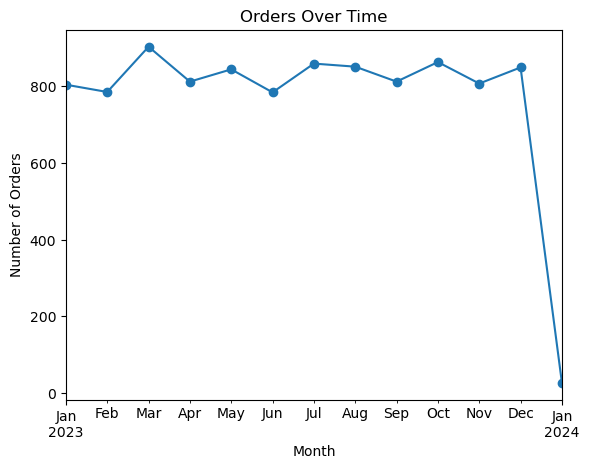

User behavior stats:
    user_id  total_orders  avg_order_amount  total_spent
0        1             1          1289.660      1289.66
1        2            10           756.412      7564.12
2        3             2           919.755      1839.51
3        4             4           935.290      3741.16
4        5             5          1148.576      5742.88
City revenue:
 city
Bangalore    2206946.58
Chennai      1990513.03
Pune         1924797.93
Hyderabad    1889366.58
Name: total_amount, dtype: float64

Cuisine revenue:
 cuisine
Mexican    2085503.09
Italian    2024203.80
Indian     1971412.58
Chinese    1930504.65
Name: total_amount, dtype: float64


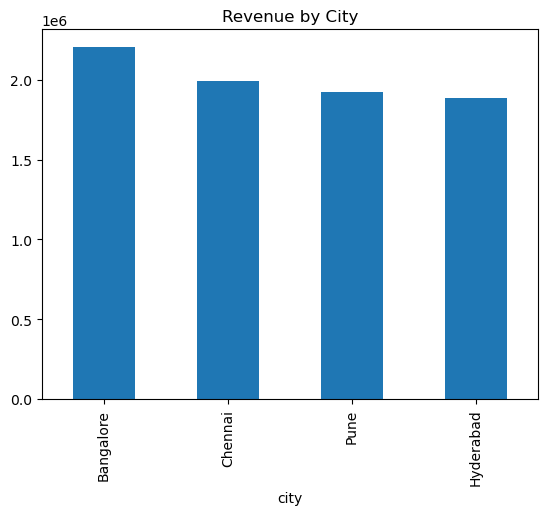

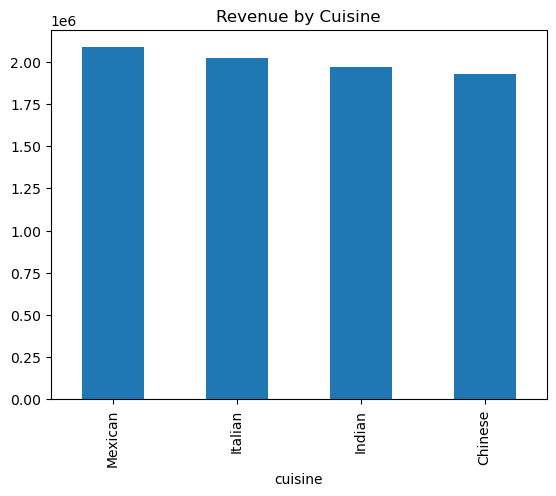

Membership impact:
             count         sum        mean
membership                               
Gold         4987  3975364.89  797.145556
Regular      5013  4036259.23  805.158434


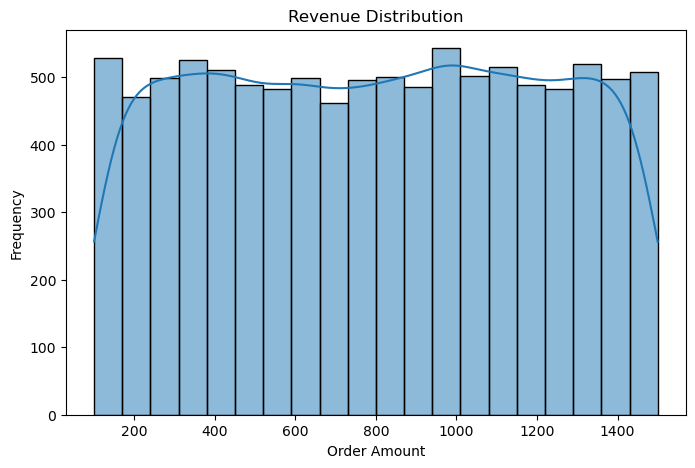

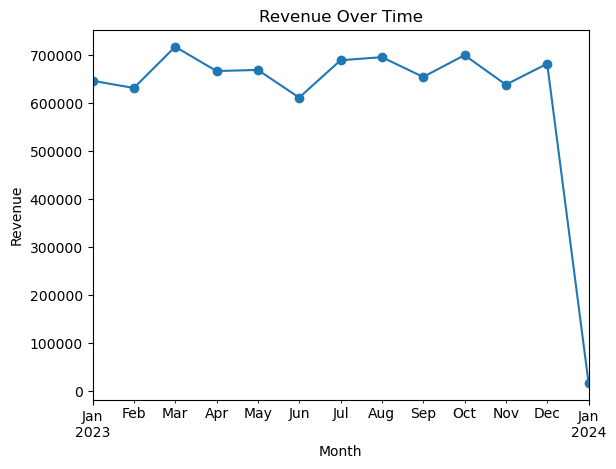

In [76]:
# 1️⃣ Load datasets
orders = pd.read_csv('orders.csv')
users = pd.read_json('users.json')
conn = sqlite3.connect('restaurants.db')
restaurants = pd.read_sql("SELECT * FROM restaurants", conn)

# 2️⃣ Merge datasets
merged_data = orders.merge(users, on='user_id', how='left')
final_dataset = merged_data.merge(restaurants, on='restaurant_id', how='left')

# 3️⃣ Fix column names
# Check columns
print(final_dataset.columns)

# Rename order amount column if needed
if 'order_amount' in final_dataset.columns:
    final_dataset.rename(columns={'order_amount': 'total_amount'}, inplace=True)

# Convert order_date to datetime
final_dataset['order_date'] = pd.to_datetime(final_dataset['order_date'], dayfirst=True, errors='coerce')

# Fill missing amount values
final_dataset['total_amount'] = final_dataset['total_amount'].fillna(0)

# 4️⃣ Order trends over time
orders_per_month = final_dataset.groupby(final_dataset['order_date'].dt.to_period('M')).size()
print("Orders per month:\n", orders_per_month)
orders_per_month.plot(kind='line', marker='o', title='Orders Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

# 5️⃣ User behavior patterns
user_stats = final_dataset.groupby('user_id')['total_amount'].agg(['count','mean','sum']).reset_index()
user_stats.rename(columns={'count':'total_orders','mean':'avg_order_amount','sum':'total_spent'}, inplace=True)
print("User behavior stats:\n", user_stats.head())

# 6️⃣ City-wise and cuisine-wise performance
city_revenue = final_dataset.groupby('city')['total_amount'].sum().sort_values(ascending=False)
cuisine_revenue = final_dataset.groupby('cuisine')['total_amount'].sum().sort_values(ascending=False)
print("City revenue:\n", city_revenue)
print("\nCuisine revenue:\n", cuisine_revenue)

# Bar plots
city_revenue.plot(kind='bar', title='Revenue by City')
plt.show()
cuisine_revenue.plot(kind='bar', title='Revenue by Cuisine')
plt.show()

# 7️⃣ Membership impact
membership_stats = final_dataset.groupby('membership')['total_amount'].agg(['count','sum','mean'])
print("Membership impact:\n", membership_stats)

# 8️⃣ Revenue distribution and seasonality
# Histogram
plt.figure(figsize=(8,5))
sns.histplot(final_dataset['total_amount'], bins=20, kde=True)
plt.title('Revenue Distribution')
plt.xlabel('Order Amount')
plt.ylabel('Frequency')
plt.show()

# Monthly revenue trend
monthly_revenue = final_dataset.groupby(final_dataset['order_date'].dt.to_period('M'))['total_amount'].sum()
monthly_revenue.plot(kind='line', marker='o', title='Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [77]:
import pandas as pd

# Ensure numeric columns
final_data['total_amount'] = pd.to_numeric(final_data['total_amount'], errors='coerce')
final_data['rating'] = pd.to_numeric(final_data['rating'], errors='coerce')
final_data['order_date'] = pd.to_datetime(final_data['order_date'], errors='coerce')

# 1️⃣ City with highest total revenue from Gold members
gold_revenue_city = final_data[final_data['membership'] == 'Gold'].groupby('city')['total_amount'].sum().sort_values(ascending=False)
print("City with highest revenue from Gold members:\n", gold_revenue_city)

# 2️⃣ Cuisine with highest average order value
avg_order_cuisine = final_data.groupby('cuisine')['total_amount'].mean().sort_values(ascending=False)
print("\nCuisine with highest average order value:\n", avg_order_cuisine)

# 3️⃣ Distinct users with total orders > 1000
user_total_amount = final_data.groupby('user_id')['total_amount'].sum()
count_users_1000 = user_total_amount[user_total_amount > 1000].count()
print("\nDistinct users with total orders > 1000:", count_users_1000)

# 4️⃣ Restaurant rating range with highest total revenue
bins = [0, 3.5, 4.0, 4.5, 5.0]
labels = ['3.0–3.5', '3.6–4.0', '4.1–4.5', '4.6–5.0']
final_data['rating_range'] = pd.cut(final_data['rating'], bins=bins, labels=labels, include_lowest=True)
revenue_by_rating = final_data.groupby('rating_range')['total_amount'].sum().sort_values(ascending=False)
print("\nRestaurant rating range with highest revenue:\n", revenue_by_rating)

# 5️⃣ Among Gold members, which city has highest average order value
gold_avg_city = final_data[final_data['membership'] == 'Gold'].groupby('city')['total_amount'].mean().sort_values(ascending=False)
print("\nCity with highest avg order value among Gold members:\n", gold_avg_city)

# 6️⃣ Cuisine with fewest restaurants but significant revenue
cuisine_stats = final_data.groupby('cuisine').agg(
    distinct_restaurants=('restaurant_id', 'nunique'),
    total_revenue=('total_amount', 'sum')
).sort_values(by=['distinct_restaurants','total_revenue'])
print("\nCuisine with few restaurants but high revenue:\n", cuisine_stats)

# 7️⃣ Percentage of total orders placed by Gold members
total_orders = len(final_data)
gold_orders = len(final_data[final_data['membership'] == 'Gold'])
percentage_gold = round((gold_orders / total_orders) * 100)
print("\nPercentage of orders by Gold members:", percentage_gold, "%")

# 8️⃣ Restaurant with highest avg order < 20 orders
restaurant_stats = final_data.groupby('restaurant_name_x').agg(
    avg_order=('total_amount', 'mean'),
    total_orders=('order_id', 'count')
)
top_restaurant = restaurant_stats[restaurant_stats['total_orders'] < 20].sort_values(by='avg_order', ascending=False)
print("\nRestaurant with highest avg order (<20 orders):\n", top_restaurant.head(1))

# 9️⃣ Membership + Cuisine combo with highest revenue
combo_revenue = final_data.groupby(['membership','cuisine'])['total_amount'].sum().sort_values(ascending=False)
print("\nCombination with highest revenue:\n", combo_revenue.head(1))

# 🔟 Quarter with highest revenue
final_data['quarter'] = final_data['order_date'].dt.quarter
revenue_by_quarter = final_data.groupby('quarter')['total_amount'].sum().sort_values(ascending=False)
print("\nQuarter with highest revenue:\n", revenue_by_quarter)

C:\Users\Nikhil Agrawal\AppData\Local\Temp\ipykernel_24896\3646626587.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  final_data['order_date'] = pd.to_datetime(final_data['order_date'], errors='coerce')
C:\Users\Nikhil Agrawal\AppData\Local\Temp\ipykernel_24896\3646626587.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_rating = final_data.groupby('rating_range')['total_amount'].sum().sort_values(ascending=False)


City with highest revenue from Gold members:
 city
Chennai      1080909.79
Pune         1003012.32
Bangalore     994702.59
Hyderabad     896740.19
Name: total_amount, dtype: float64

Cuisine with highest average order value:
 cuisine
Mexican    808.021344
Italian    799.448578
Indian     798.466011
Chinese    798.389020
Name: total_amount, dtype: float64

Distinct users with total orders > 1000: 2544

Restaurant rating range with highest revenue:
 rating_range
4.6–5.0    2197030.75
3.0–3.5    2136772.70
4.1–4.5    1960326.26
3.6–4.0    1717494.41
Name: total_amount, dtype: float64

City with highest avg order value among Gold members:
 city
Chennai      808.459080
Hyderabad    806.421034
Bangalore    793.223756
Pune         781.162243
Name: total_amount, dtype: float64

Cuisine with few restaurants but high revenue:
          distinct_restaurants  total_revenue
cuisine                                     
Chinese                   120     1930504.65
Indian                    126     19

In [78]:
# Filter orders for Gold members
gold_orders = final_data[final_data['membership'] == 'Gold']

# Count total orders
total_gold_orders = gold_orders['order_id'].count()

print("Total orders placed by Gold members:", total_gold_orders)

# Filter orders from Hyderabad
hyderabad_orders = final_data[final_data['city'] == 'Hyderabad']

# Sum total revenue and round
total_revenue_hyderabad = round(hyderabad_orders['total_amount'].sum())

print("Total revenue from Hyderabad orders:", total_revenue_hyderabad)

# Count distinct users
distinct_users = final_data['user_id'].nunique()

print("Number of distinct users who placed at least one order:", distinct_users)

# Filter for Gold members
gold_orders = final_data[final_data['membership'] == 'Gold']

# Calculate average order value
avg_order_value_gold = round(gold_orders['total_amount'].mean(), 2)

print("Average order value for Gold members:", avg_order_value_gold)

# Filter orders for restaurants with rating >= 4.5
high_rating_orders = final_data[final_data['rating'] >= 4.5]

# Count total orders
total_high_rating_orders = high_rating_orders['order_id'].count()

print("Total orders for restaurants with rating >= 4.5:", total_high_rating_orders)


# Step 1: Find the top revenue city among Gold members
gold_data = final_data[final_data['membership'] == 'Gold']
top_city = gold_data.groupby('city')['total_amount'].sum().idxmax()  # city with highest revenue

# Step 2: Count orders in that city for Gold members
orders_top_city_gold = gold_data[gold_data['city'] == top_city]['order_id'].count()

print("Top revenue city among Gold members:", top_city)
print("Number of orders in that city by Gold members:", orders_top_city_gold)

Total orders placed by Gold members: 4987
Total revenue from Hyderabad orders: 1889367
Number of distinct users who placed at least one order: 2883
Average order value for Gold members: 797.15
Total orders for restaurants with rating >= 4.5: 3374
Top revenue city among Gold members: Chennai
Number of orders in that city by Gold members: 1337
